# RF-DETR Training — Floor Plan Detection

Trains **RF-DETR-2XLarge** (largest available model) on the merged cubicasa5k + floor-plan-ai-combined dataset.

**Model:** RF-DETR-2XLarge — 880×880, 126.9M params, 78.5 AP₅₀ on COCO (requires `rfdetr[plus]`)

**Classes:** `door` (0), `wall` (1), `window` (2)

**Dataset splits after merge:**
- train: 6,648 images
- valid: 1,310 images
- test: 1,314 images

**Pipeline:**
1. Install dependencies
2. Convert YOLO → COCO format (required by RF-DETR)
3. Train RF-DETR-2XLarge

4. Evaluate on test set5. Run inference on a sample image

## 1. Install Dependencies

In [1]:
# Uncomment and run once to install dependencies
# RF-DETR-2XLarge requires the rfdetr[plus] extension
# !pip install "rfdetr[plus]" supervision torch torchvision

## 2. Environment Check

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
    print("Torch CUDA:", torch.version.cuda)

CUDA available: True
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB
Torch CUDA: 12.8


In [2]:
from pathlib import Path

YOLO_ROOT = Path("../data/cubicasa5k-2.v6i.yolov12")
COCO_ROOT = Path("../data/cubicasa5k-2.v6i.coco")
SPLITS = ["train", "valid", "test"]
CLASS_NAMES = ["door", "wall", "window"]

DATASET_DIR = str((COCO_ROOT).resolve())
OUTPUT_DIR  = "runs/rfdetr_2xlarge_floorplan"

## 3. Convert YOLO Dataset → COCO Format

RF-DETR expects each split directory to contain:
- `_annotations.coco.json` — COCO-format annotations
- All image files (flat, in the same directory)

We use `supervision` to read YOLO labels and write COCO JSON.

In [4]:
# import os
# import json
# import shutil

# from PIL import Image as PILImage

# YOLO_ROOT = Path("../data/cubicasa5k-2.v6i.yolov12")
# COCO_ROOT = Path("../data/cubicasa5k-coco")
# SPLITS = ["train", "valid", "test"]
# CLASS_NAMES = ["door", "wall", "window"]

# def yolo_split_to_coco(split: str):
#     src_images = YOLO_ROOT / split / "images"
#     src_labels = YOLO_ROOT / split / "labels"
#     dst_dir = COCO_ROOT / split
#     dst_dir.mkdir(parents=True, exist_ok=True)

#     categories = [{"id": i, "name": n, "supercategory": "none"} for i, n in enumerate(CLASS_NAMES)]
#     coco_images, coco_annotations, ann_id = [], [], 1

#     image_files = sorted(p for p in src_images.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png"))

#     for img_id, img_path in enumerate(image_files, start=1):
#         with PILImage.open(img_path) as img:
#             w, h = img.size
#         shutil.copy2(img_path, dst_dir / img_path.name)
#         coco_images.append({"id": img_id, "file_name": img_path.name, "width": w, "height": h})

#         lbl_path = src_labels / (img_path.stem + ".txt")
#         if not lbl_path.exists():
#             continue
#         with open(lbl_path) as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if len(parts) != 5:
#                     continue
#                 cls = int(parts[0])
#                 if cls >= len(CLASS_NAMES):
#                     continue
#                 cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
#                 abs_w, abs_h = bw * w, bh * h
#                 x, y = (cx - bw / 2) * w, (cy - bh / 2) * h
#                 coco_annotations.append({
#                     "id": ann_id,
#                     "image_id": img_id,
#                     "category_id": cls,
#                     "bbox": [round(x, 2), round(y, 2), round(abs_w, 2), round(abs_h, 2)],
#                     "area": round(abs_w * abs_h, 2),
#                     "iscrowd": 0,
#                 })
#                 ann_id += 1

#     with open(dst_dir / "_annotations.coco.json", "w") as f:
#         json.dump({"categories": categories, "images": coco_images, "annotations": coco_annotations}, f)
#     print(f"[{split}] {len(coco_images)} images, {len(coco_annotations)} annotations → {dst_dir}")


# if not (COCO_ROOT / "train" / "_annotations.coco.json").exists():
#     for split in SPLITS:
#         yolo_split_to_coco(split)
#     print("\nConversion complete.")
# else:
#     print("COCO dataset already exists at:", COCO_ROOT.resolve())
#     for split in SPLITS:
#         n = len(list((COCO_ROOT / split).glob("*.jpg"))) + len(list((COCO_ROOT / split).glob("*.png")))
#         print(f"  {split}: {n} images")

## 4. Train RF-DETR-2XLarge

**Model choice:** RF-DETR-2XLarge (880×880, 126.9M params, 78.5 AP₅₀ on COCO) — largest available model

> ⚠️ Requires `pip install "rfdetr[plus]"` and PML 1.0 license.

**Batch size guidance (VRAM):**
| VRAM | `batch_size` | `grad_accum_steps` | Effective batch |
|------|--------------|---------------------|------------------|
| 16 GB | 1 | 16 | 16 |
| 24 GB | 2 | 8 | 16 |

| 40 GB | 4 | 4 | 16 || 80 GB | 8 | 2 | 16 |

In [6]:
from rfdetr import RFDETR2XLarge



# Adjust batch_size / grad_accum_steps to your VRAM (keep effective batch = 16)
# 2XLarge is very large — reduce batch_size if you get OOM
BATCH_SIZE       = 2   # per-GPU batch (needs ~24 GB VRAM at bs=2)
GRAD_ACCUM_STEPS = 8   # effective batch = BATCH_SIZE * GRAD_ACCUM_STEPS
EPOCHS           = 100
LR               = 1e-4

model = RFDETR2XLarge()

model.train(
    dataset_dir=DATASET_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    lr=LR,
    output_dir=OUTPUT_DIR,
    checkpoint_interval=10,  # save every 10 epochs
    early_stopping=True,
    early_stopping_patience=20,
    run_test=True,           # evaluate on test split after training
    tensorboard=True,
)

[2026-04-05 00:22:54] [INFO] rf-detr - File rf-detr-xxlarge.pth already exists with correct MD5 hash.


[2026-04-05 00:22:54] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-05 00:22:54] [WARNING] rf-detr - Using patch size 20 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-05 00:23:12] [INFO] rf-detr - File rf-detr-xxlarge.pth already exists with correct MD5 hash.


[2026-04-05 00:23:14] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 365. Using checkpoint class count (90). Pass num_classes=90 to suppress this warning.
[2026-04-05 00:23:15] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-05 00:23:15] [WARNING] rf-detr - Using patch size 20 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-05 00:23:33] [INFO] rf-detr - File rf-detr-xxlarge.pth already exists with correct MD5 hash.


...

[2026-04-05 04:53:53] [INFO] rf-detr - Best regular mAP saved to /mnt/c/Users/ryan/Documents/GitHub/construction-ai/datascience/runs/rfdetr_2xlarge_floorplan/checkpoint_best_regular.pth (epoch 26)
[2026-04-05 04:53:56] [INFO] rf-detr - Best EMA mAP improved to 0.3839 (epoch 26)


Monitored metric __rfdetr_effective_map__ did not improve in the last 20 records. Best score: 0.384. Signaling Trainer to stop.


[2026-04-05 15:14:12] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.3826, ema=0.3839)
[2026-04-05 15:14:15] [INFO] rf-detr - Loaded best weights from /mnt/c/Users/ryan/Documents/GitHub/construction-ai/datascience/runs/rfdetr_2xlarge_floorplan/checkpoint_best_total.pth for test evaluation.
[2026-04-05 15:14:15] [INFO] rf-detr - Building Roboflow test dataset with square resize at resolution 880
[2026-04-05 15:14:15] [INFO] rf-detr - Using multi-scale training with square resize and scales: [1080]
[2026-04-05 15:14:15] [INFO] rf-detr - Built 1 Albumentations transforms from config


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


## 5. Plot Training Metrics

['epoch', 'step', 'test/AP/door', 'test/AP/wall', 'test/AP/window', 'test/F1', 'test/loss', 'test/mAP_50', 'test/mAP_50_95', 'test/mAP_75', 'test/mAR', 'test/precision', 'test/recall', 'train/cardinality_error', 'train/cardinality_error_0', 'train/cardinality_error_1', 'train/cardinality_error_2', 'train/cardinality_error_3', 'train/cardinality_error_enc', 'train/class_error', 'train/loss', 'train/loss_bbox', 'train/loss_bbox_0', 'train/loss_bbox_1', 'train/loss_bbox_2', 'train/loss_bbox_3', 'train/loss_bbox_enc', 'train/loss_ce', 'train/loss_ce_0', 'train/loss_ce_1', 'train/loss_ce_2', 'train/loss_ce_3', 'train/loss_ce_enc', 'train/loss_giou', 'train/loss_giou_0', 'train/loss_giou_1', 'train/loss_giou_2', 'train/loss_giou_3', 'train/loss_giou_enc', 'train/lr', 'train/lr_max', 'train/lr_min', 'val/AP/door', 'val/AP/wall', 'val/AP/window', 'val/F1', 'val/ema_mAP_50', 'val/ema_mAP_50_95', 'val/ema_mAR', 'val/loss', 'val/mAP_50', 'val/mAP_50_95', 'val/mAP_75', 'val/mAR', 'val/precision', 

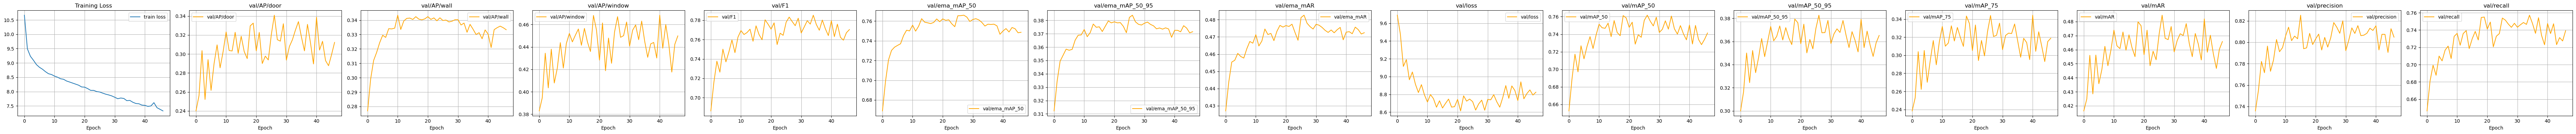

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

metrics_csv = os.path.join(OUTPUT_DIR, "metrics.csv")
if not os.path.exists(metrics_csv):
    print("metrics.csv not found — check OUTPUT_DIR:", OUTPUT_DIR)
else:
    df = pd.read_csv(metrics_csv)
print(df.columns.tolist())
train_df = df[df["train/loss"].notna()][["epoch", "train/loss"]].drop_duplicates("epoch")
val_cols  = [c for c in df.columns if c.startswith("val/")]

fig, axes = plt.subplots(1, 1 + len(val_cols), figsize=(5 * (1 + len(val_cols)), 4))
if len(val_cols) == 0:
    axes = [axes]

axes[0].plot(train_df["epoch"], train_df["train/loss"], label="train loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

for ax, col in zip(axes[1:], val_cols):
    val_df = df[df[col].notna()][["epoch", col]].drop_duplicates("epoch")
    ax.plot(val_df["epoch"], val_df[col], label=col, color="orange")
    ax.set_title(col)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "metrics_plot.png"), dpi=150)
plt.show()


## 6. Evaluate Best Checkpoint on Test Set

In [4]:
import supervision as sv
from rfdetr import RFDETR2XLarge
from PIL import Image
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

BEST_WEIGHTS = os.path.join(OUTPUT_DIR, "checkpoint_best_total.pth")

eval_model = RFDETR2XLarge(pretrain_weights=BEST_WEIGHTS)
eval_model.optimize_for_inference()

test_ds = sv.DetectionDataset.from_coco(
    images_directory_path=str(COCO_ROOT / "test"),
    annotations_path=str(COCO_ROOT / "test" / "_annotations.coco.json"),
)

targets = []
predictions = []

for path, image, annotations in tqdm(test_ds, desc="Evaluating"):
    pil_img = Image.open(path)
    raw = eval_model.predict(pil_img, threshold=0.0)
    # Reconstruct clean Detections — rfdetr's data dict contains entries
    # (e.g. source_shape, mismatched arrays) that break supervision's metrics.
    detections = sv.Detections(
        xyxy=raw.xyxy,
        confidence=raw.confidence,
        class_id=raw.class_id,
    )
    targets.append(annotations)
    predictions.append(detections)

map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)


[2026-04-05 15:18:30] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-05 15:18:30] [WARNING] rf-detr - Using patch size 20 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-05 15:18:34] [WARNING] rf-detr - Checkpoint has 4 classes but model is configured for 365. Using checkpoint class count (4). Pass num_classes=4 to suppress this warning.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`use_return_dict` is deprecated! Use `return_dict` instead!
Evaluating: 100%|██████████| 400/400 [00:12<00:00, 31.37it/s]


Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.390
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.759
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.356
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.349
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.615
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.430


## 7. Visualize Sample Predictions

Category map: {0: 'cubicasa5k-2', 1: 'door', 2: 'wall', 3: 'window'}


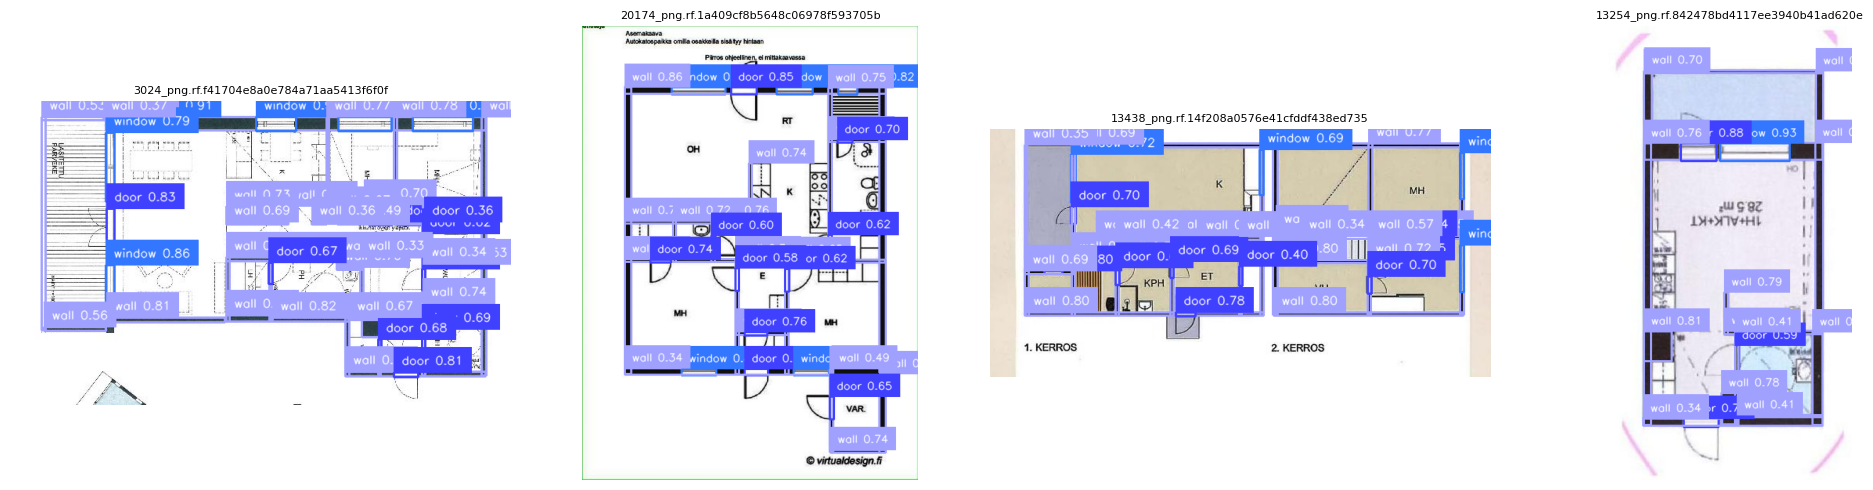

In [13]:
import random
import json
import numpy as np
import supervision as sv
import matplotlib.pyplot as plt
from PIL import Image

# Load id→name from the annotation file so class IDs always match correctly
with open(COCO_ROOT / "test" / "_annotations.coco.json") as f:
    _coco = json.load(f)
ID_TO_NAME = {cat["id"]: cat["name"] for cat in _coco["categories"]}
print("Category map:", ID_TO_NAME)

CONF_THRESHOLD = 0.3
NUM_SAMPLES = 4

test_images = list((COCO_ROOT / "test").glob("*.jpg")) + \
              list((COCO_ROOT / "test").glob("*.png"))
samples = random.sample(test_images, min(NUM_SAMPLES, len(test_images)))

fig, axes = plt.subplots(1, NUM_SAMPLES, figsize=(20, 5))
box_ann   = sv.BoxAnnotator(thickness=2)
label_ann = sv.LabelAnnotator(text_scale=0.5)

for ax, img_path in zip(axes, samples):
    pil_img = Image.open(img_path).convert("RGB")
    detections = eval_model.predict(pil_img, threshold=CONF_THRESHOLD)

    labels = [
        f"{ID_TO_NAME.get(c, str(c))} {sc:.2f}"
        for c, sc in zip(detections.class_id, detections.confidence)
    ]

    frame = np.array(pil_img)
    frame = box_ann.annotate(frame, detections)
    frame = label_ann.annotate(frame, detections, labels)

    ax.imshow(frame)
    ax.set_title(img_path.name[:40], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_predictions.png"), dpi=150)
plt.show()


### Predict on a specific image

In [14]:
import numpy as np
import json
import matplotlib.pyplot as plt
import supervision as sv
from PIL import Image

SPECIFIC_IMAGE = "runs/predict/floor_plan_boundary_detection/example_page_1_floorplan_2.png"

# Load id→name mapping from the annotation file
with open(COCO_ROOT / "test" / "_annotations.coco.json") as f:
    _coco = json.load(f)
ID_TO_NAME = {cat["id"]: cat["name"] for cat in _coco["categories"]}
print("Category map:", ID_TO_NAME)

pil_img = Image.open(SPECIFIC_IMAGE).convert("RGB")

# --- diagnostic: get ALL detections at threshold=0.0 to inspect scores ---
raw = eval_model.predict(pil_img, threshold=0.0)
print(f"Total raw detections (threshold=0.0): {len(raw)}")
if len(raw) > 0:
    scores = np.sort(raw.confidence)[::-1]
    print(f"Top-20 confidence scores: {scores[:20].round(3)}")
    print(f"Class IDs in output: {sorted(set(raw.class_id.tolist()))}")
    print(f"Score percentiles — 50%: {np.percentile(scores, 50):.3f}  "
          f"75%: {np.percentile(scores, 75):.3f}  "
          f"90%: {np.percentile(scores, 90):.3f}  "
          f"95%: {np.percentile(scores, 95):.3f}")
else:
    print("No detections at all — check that eval_model is loaded with the correct weights.")


Category map: {0: 'cubicasa5k-2', 1: 'door', 2: 'wall', 3: 'window'}
Total raw detections (threshold=0.0): 300
Top-20 confidence scores: [0.803 0.799 0.794 0.781 0.777 0.77  0.768 0.768 0.767 0.75  0.742 0.738
 0.737 0.734 0.721 0.711 0.699 0.68  0.678 0.678]
Class IDs in output: [1, 2, 3]
Score percentiles — 50%: 0.095  75%: 0.251  90%: 0.627  95%: 0.712


Detections at threshold=0.5: 42


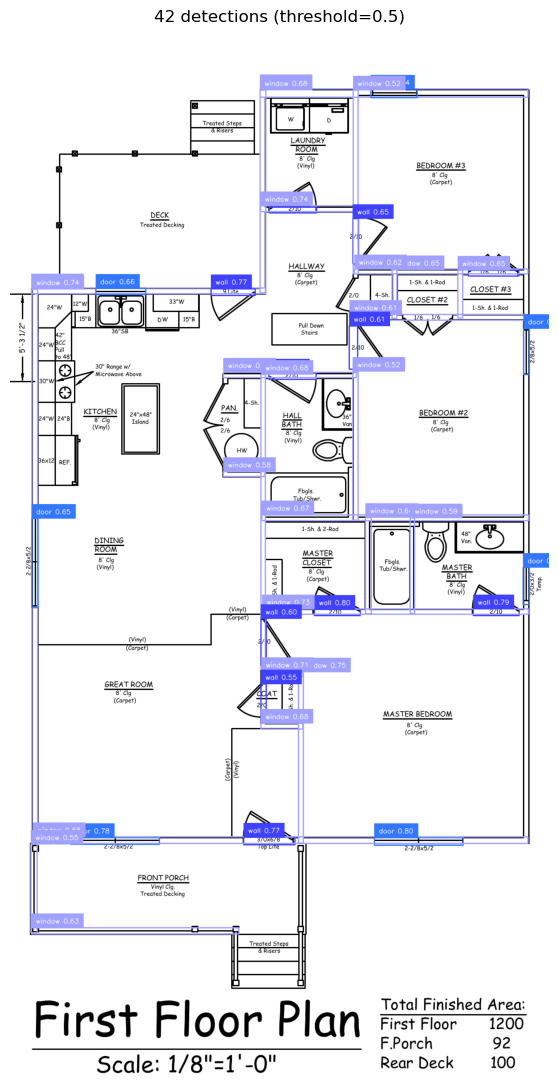

Saved to: runs/predict/floor_plan_boundary_detection/example_page_1_floorplan_2_rfdetr.png


In [ ]:
# --- visualize at a chosen threshold after inspecting scores above ---
CONF_THRESHOLD = 0.2

detections = eval_model.predict(pil_img, threshold=CONF_THRESHOLD)
print(f"Detections at threshold={CONF_THRESHOLD}: {len(detections)}")

labels = [
    f"{ID_TO_NAME.get(c, str(c))} {sc:.2f}"
    for c, sc in zip(detections.class_id, detections.confidence)
]

frame = np.array(pil_img)
frame = sv.BoxAnnotator(thickness=2).annotate(frame, detections)
frame = sv.LabelAnnotator(text_scale=0.5).annotate(frame, detections, labels)

plt.figure(figsize=(14, 11))
plt.imshow(frame)
plt.title(f"{len(detections)} detections (threshold={CONF_THRESHOLD})")
plt.axis("off")
plt.tight_layout()
out_path = "runs/predict/floor_plan_boundary_detection/example_page_1_floorplan_2_rfdetr.png"
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Saved to: {out_path}")


## 8. Export Model for Inference

In [ ]:
# Optimize & save for deployment
eval_model.optimize_for_inference()
print("Model ready for inference.")
print("Best weights:", os.path.abspath(BEST_WEIGHTS))